# ApplyEngine — Tailoring Evals

Measures whether the tailoring pipeline actually improves **ATS keyword coverage**
against a set of (resume, job description) pairs, and reports the blended **fit score**.

Runs fully offline with the `mock` provider (no API keys). Set `LLM_PROVIDER=openai`
(and an API key) in `backend/.env` to evaluate a real model instead.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parents[0] if Path.cwd().name == "evals" else Path.cwd()
sys.path.insert(0, str(ROOT / "backend"))
sys.path.insert(0, str(ROOT / "evals"))

import pandas as pd
from run_evals import run_case
from dataset import CASES

df = pd.DataFrame(run_case(c) for c in CASES).set_index("id")
df

,n_keywords,keyword_coverage_before,keyword_coverage_after,coverage_lift,fit_score,parse_ok
id,,,,,,
ds_churn,11,0.364,1.0,0.636,33.7,True
ai_llm,11,0.545,1.0,0.455,47.1,True
analyst_stretch,9,0.222,1.0,0.778,18.7,True


/var/folders/52/jg6y7fv50qd0spy0gnm5df740000gn/T/ipykernel_3494/1546103237.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(df.index, rotation=20)


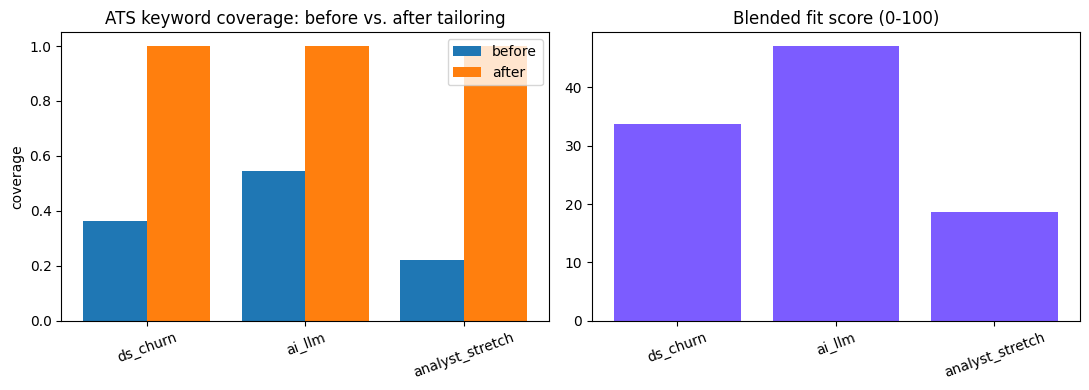

Average coverage lift: 0.623
Average fit score: 33.2


In [2]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

x = range(len(df))
ax1.bar([i - 0.2 for i in x], df["keyword_coverage_before"], width=0.4, label="before")
ax1.bar([i + 0.2 for i in x], df["keyword_coverage_after"], width=0.4, label="after")
ax1.set_xticks(list(x)); ax1.set_xticklabels(df.index, rotation=20)
ax1.set_title("ATS keyword coverage: before vs. after tailoring")
ax1.set_ylabel("coverage"); ax1.legend()

ax2.bar(df.index, df["fit_score"], color="#7c5cff")
ax2.set_xticklabels(df.index, rotation=20)
ax2.set_title("Blended fit score (0-100)")

plt.tight_layout()
plt.savefig(ROOT / "evals" / "coverage.png", dpi=120, bbox_inches="tight")
plt.show()

print("Average coverage lift:", round(df["coverage_lift"].mean(), 3))
print("Average fit score:", round(df["fit_score"].mean(), 1))